In [2]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [3]:
def loadData(fileName, inputVariableNames, outputVariableName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for line_count, row in enumerate(csv_reader):
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
    if isinstance(inputVariableNames, str):
        inputVariableNames = [inputVariableNames]
    selectedVariables = [dataNames.index(name) for name in inputVariableNames]
    selectedOutput = dataNames.index(outputVariableName)
    inputs = []
    outputs = []
    for row in data:
        if any(row[i]=='' for i in selectedVariables) or row[selectedOutput]=='':
            continue
        inputs.append([float(row[i]) for i in selectedVariables])
        outputs.append(float(row[selectedOutput]))
    return inputs, outputs

def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

def plotData(inputs, outputs, x2=None, y2=None, x3=None, y3=None, title=None):
    inputs = np.array(inputs)
    outputs = np.array(outputs)
    fig = plt.figure()
    # 1D input: 2D plot
    if inputs.ndim == 1 or (inputs.ndim == 2 and inputs.shape[1] == 1):
        plt.plot(inputs, outputs, 'ro', label='train data')
        if x2 is not None and y2 is not None and len(x2) > 0:
            plt.plot(x2, y2, 'b-', label='learnt model')
        if x3 is not None and y3 is not None and len(x3) > 0:
            plt.plot(x3, y3, 'g^', label='test data')
        plt.xlabel('Input')
        plt.ylabel('Output')
    # 2D input: 3D plot
    elif inputs.ndim == 2 and inputs.shape[1] == 2:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(inputs[:,0], inputs[:,1], outputs, c='r', marker='o', label='train data')
        if x2 is not None and y2 is not None and len(x2) > 0:
            x2 = np.array(x2)
            y2 = np.array(y2)
            if x2.ndim == 2 and x2.shape[1] == 2:
                ax.plot(x2[:,0], x2[:,1], y2, 'b-', label='learnt model')
        if x3 is not None and y3 is not None and len(x3) > 0:
            x3 = np.array(x3)
            y3 = np.array(y3)
            if x3.ndim == 2 and x3.shape[1] == 2:
                ax.scatter(x3[:,0], x3[:,1], y3, c='g', marker='^', label='test data')
        ax.set_xlabel('Input 1')
        ax.set_ylabel('Input 2')
        ax.set_zlabel('Output')
    else:
        raise ValueError("plotData only supports 1D or 2D inputs.")
    if title:
        plt.title(title)
    plt.legend()
    plt.show()

def plot3DData(inputs, outputs):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    xs = [i[0] for i in inputs]
    ys = [i[1] for i in inputs]
    ax.scatter(xs, ys, outputs)
    ax.set_xlabel('Input 1')
    ax.set_ylabel('Input 2')
    ax.set_zlabel('Output')
    plt.show()


In [4]:
def trainHappinessModel(inputs,outputs,firstInputName=None,secondInputName=None):
    # check liniarity relationship
    title='Happiness vs '+ (firstInputName + ' and ' + secondInputName if secondInputName else firstInputName)

    # split data into train and test
    np.random.seed(5)
    indexes=[i for i in range(len(inputs))]
    trainSample=np.random.choice(indexes,int(0.8*len(indexes)),replace=False)
    validationSample=[i for i in indexes if i not in trainSample]

    # separate train and test data
    inputsTrain=[inputs[i] for i in trainSample]
    inputsValidation=[inputs[i] for i in validationSample]
    outputsTrain=[outputs[i] for i in trainSample]
    outputsValidation=[outputs[i] for i in validationSample]

    # train model
    regressor = linear_model.LinearRegression()
    regressor.fit(inputsTrain, outputsTrain)
    w0,w1=regressor.intercept_,regressor.coef_

    inputsTrain_np = np.array(inputsTrain)
    noOfPoints = 1000

    if inputsTrain_np.shape[1] == 1:
        # 1D: plot regression line
        xref = np.linspace(inputsTrain_np[:, 0].min(), inputsTrain_np[:, 0].max(), noOfPoints).reshape(-1, 1)
        yref = regressor.predict(xref)
        plotData(inputsTrain, outputsTrain, xref, yref, [], [], title="Training Data and Model")
    elif inputsTrain_np.shape[1] == 2:
        # 2D: plot regression plane
        x1 = np.linspace(inputsTrain_np[:, 0].min(), inputsTrain_np[:, 0].max(), 20)
        x2 = np.linspace(inputsTrain_np[:, 1].min(), inputsTrain_np[:, 1].max(), 20)
        x1_grid, x2_grid = np.meshgrid(x1, x2)
        x_pred = np.c_[x1_grid.ravel(), x2_grid.ravel()]
        y_pred = regressor.predict(x_pred).reshape(x1_grid.shape)

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(inputsTrain_np[:, 0], inputsTrain_np[:, 1], outputsTrain, c='r', marker='o', label='train data')
        ax.plot_surface(x1_grid, x2_grid, y_pred, color='b', alpha=0.5)
        ax.set_xlabel(firstInputName)
        ax.set_ylabel(secondInputName)
        ax.set_zlabel('Happiness output')
        plt.title("Training Data and Model")
        plt.legend()
        plt.show()

    # predict test data and plot
    computedValidationOutputs=regressor.predict(inputsValidation)
    plt.figure()
    plt.plot(outputsValidation, computedValidationOutputs, 'g^', label='predicted vs real data')
    plt.plot([min(outputsValidation), max(outputsValidation)],
             [min(outputsValidation), max(outputsValidation)],
             'b-', label='perfect prediction')
    plt.xlabel('Real Test Output')
    plt.ylabel('Predicted Test Output')
    plt.title('Parity Plot: Predicted vs Real Test Output')
    plt.legend()
    plt.show()

    # compute evaluation metrics
    MSE=mean_squared_error(outputsValidation, computedValidationOutputs)
    RMSE=root_mean_squared_error(outputsValidation, computedValidationOutputs)
    print("MSE: ", MSE)
    print("RMSE: ", RMSE)

In [5]:
def runTests(filePath):
    inputs, outputs=loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')
    trainHappinessModel(inputs, outputs, firstInputName = 'Economy..GDP.per.Capita.')

    inputs,outputs=loadData(filePath, 'Family', 'Happiness.Score')
    trainHappinessModel(inputs, outputs, firstInputName = 'Family')

    inputs,outputs=loadData(filePath, ['Economy..GDP.per.Capita.','Freedom'], 'Happiness.Score')
    trainHappinessModel(inputs, outputs, firstInputName = 'Economy..GDP.per.Capita.', secondInputName = 'Freedom')


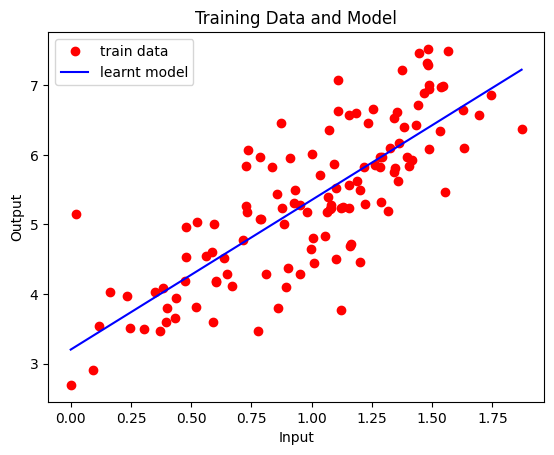

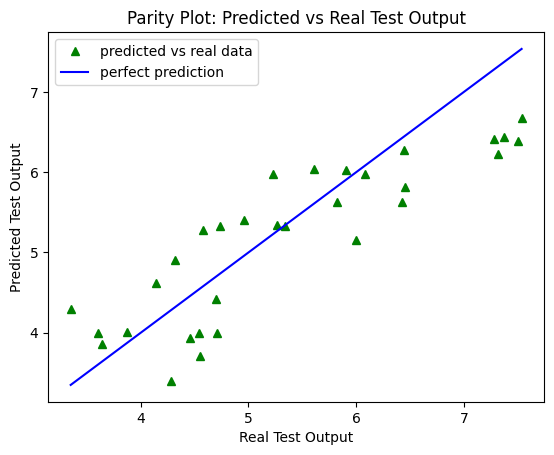

MSE:  0.41421204385052524
RMSE:  0.6435930731840774


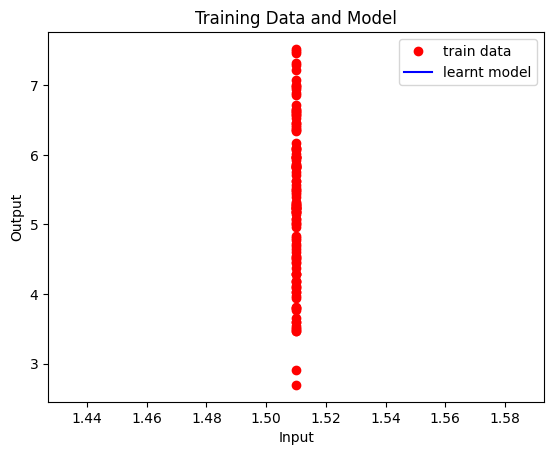

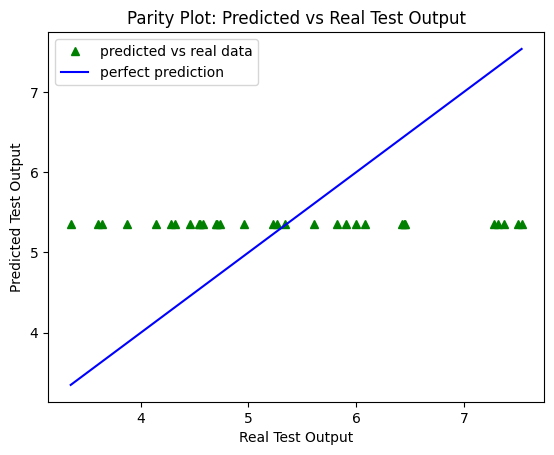

MSE:  1.488969965516146
RMSE:  1.2202335700660534


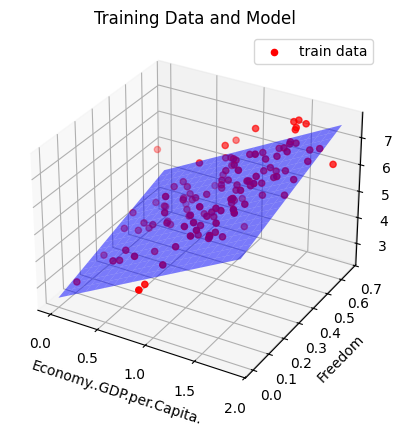

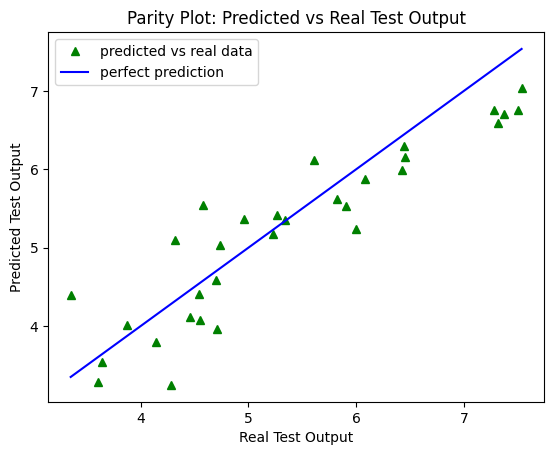

MSE:  0.2778267436200108
RMSE:  0.5270927277244591


In [6]:
# 1. v1_world-happiness-report-2017.csv folosind tools
crtDir=os.getcwd()
filePath=os.path.join(crtDir, 'data','v1_world-happiness-report-2017.csv')
runTests(filePath)

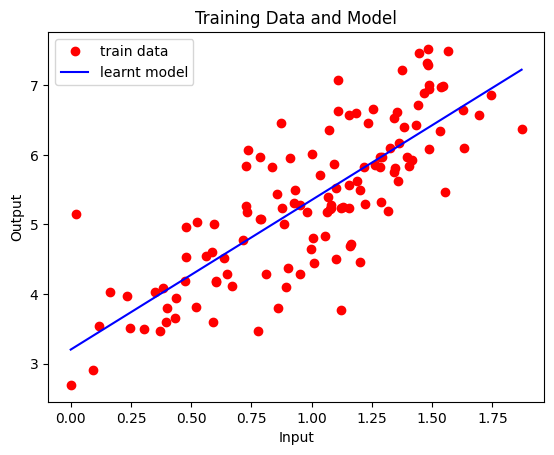

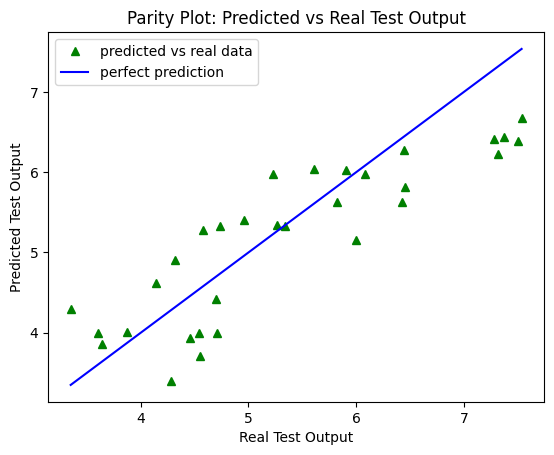

MSE:  0.41421204385052524
RMSE:  0.6435930731840774


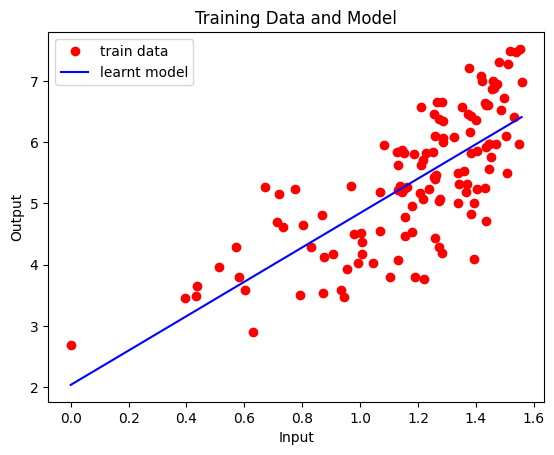

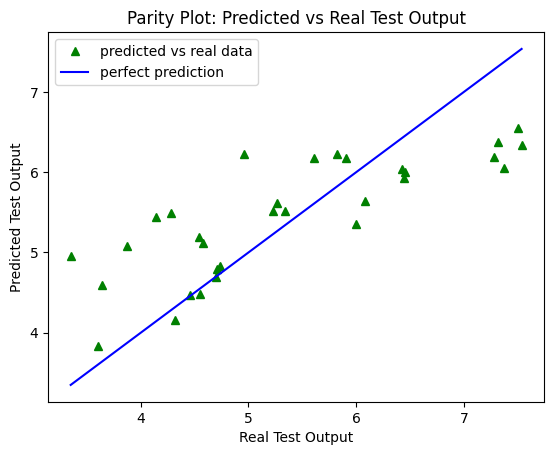

MSE:  0.6051231125473606
RMSE:  0.7778965950223465


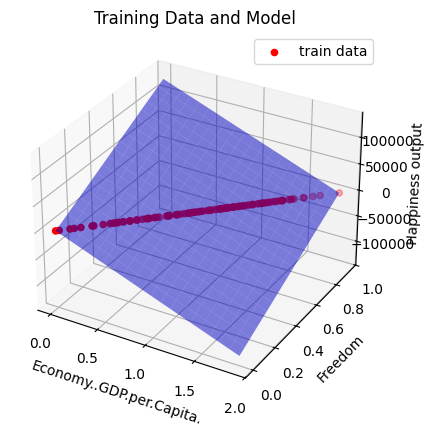

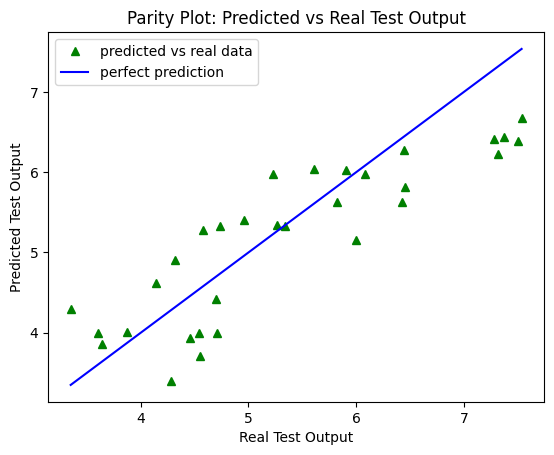

MSE:  0.4142102429499823
RMSE:  0.6435916740837954


In [7]:
# 3. v2_world-happiness-report-2017.csv folosind tools
filePath=os.path.join(crtDir, 'data','v2_world-happiness-report-2017.csv')
runTests(filePath)

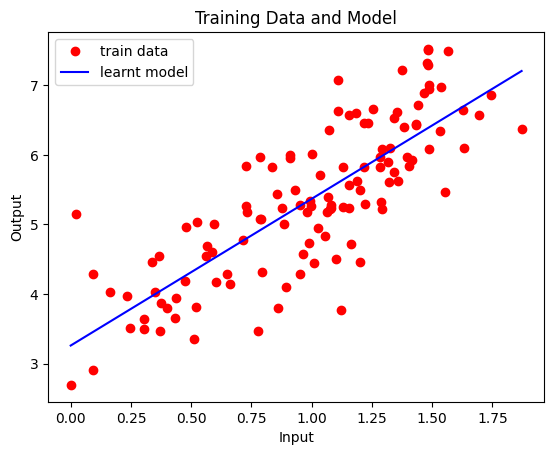

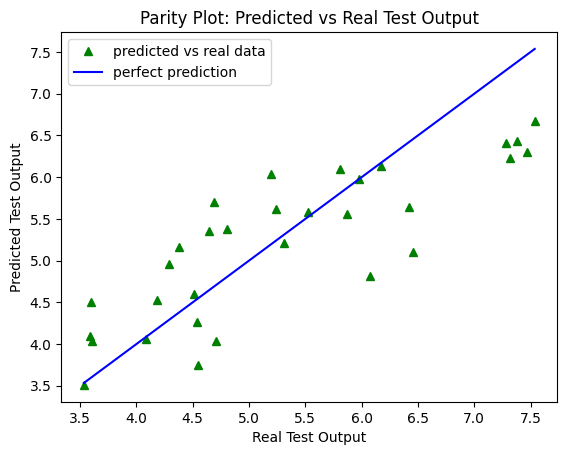

MSE:  0.5011920687289554
RMSE:  0.7079491992572315


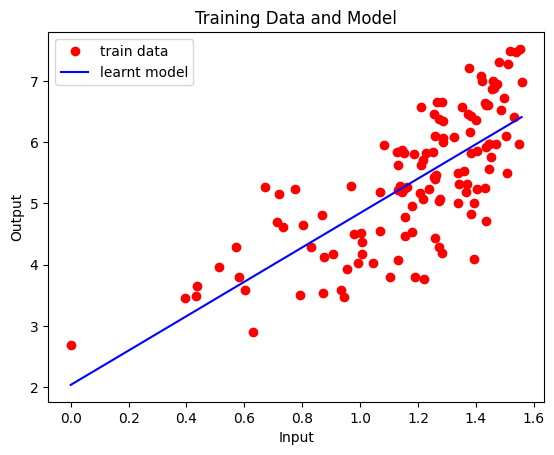

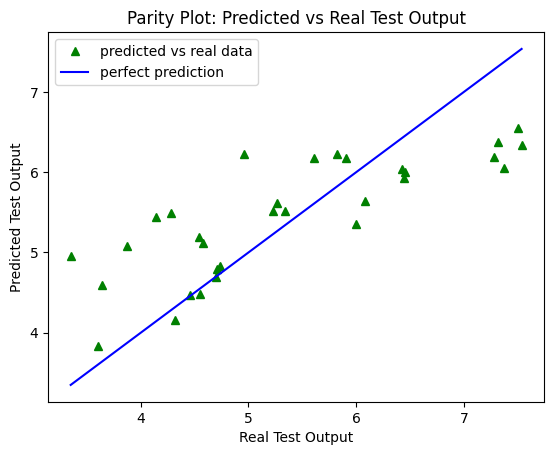

MSE:  0.6051231125473606
RMSE:  0.7778965950223465


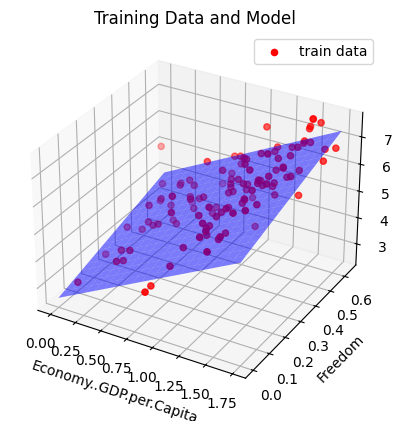

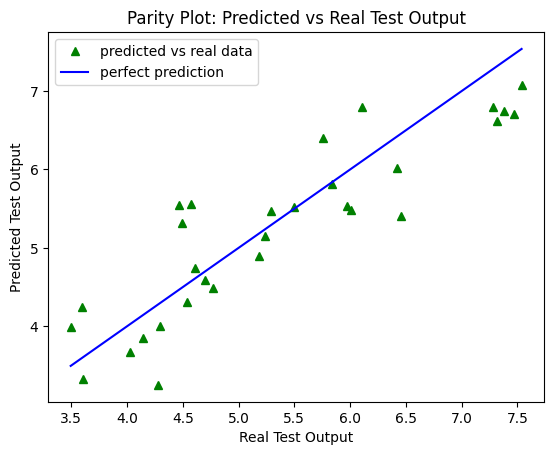

MSE:  0.32390536145644067
RMSE:  0.5691268412721725


In [8]:
# 4. v3_world-happiness-report-2017.csv folosind tools
filePath=os.path.join(crtDir, 'data','v3_world-happiness-report-2017.csv')
runTests(filePath)

In [9]:
class MyLinearUnivariateRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = 0.0

    # learn a linear univariate regression model by using training inputs (x) and outputs (y)
    def fit(self, x, y):
        if isinstance(x[0], list):
            x = [val[0] for val in x]
        sx = sum(x)
        sy = sum(y)
        sx2 = sum(i * i for i in x)
        sxy = sum(i * j for (i,j) in zip(x, y))
        w1 = (len(x) * sxy - sx * sy) / (len(x) * sx2 - sx * sx)
        w0 = (sy - w1 * sx) / len(x)
        self.intercept_, self.coef_ =  w0, w1

    # predict the outputs for some new inputs (by using the learnt model)
    def predict(self, x):
        if (isinstance(x[0], list)):
            return [self.intercept_ + self.coef_ * val[0] for val in x]
        else:
            return [self.intercept_ + self.coef_ * val for val in x]

class MyLinearMultivariateRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x, y):

        X = np.array(x)
        Y = np.array(y)

        # aduag o coloana de 1 in fata matrici ca sa putem calcula w0 w1 w2 direct cu formula normala

        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)

        # Aplicăm formula normală: W = (X^T * X)^-1 * X^T * Y
        # Aceasta găsește direct valorile optime pentru w0, w1, w2
        W = np.linalg.inv(X.T @ X) @ X.T @ Y

        self.intercept_ = W[0]
        self.coef_ = W[1:]

    def predict(self, x):
        results = []
        for row in x:
            # y = w0 + w1*x1 + w2*x2
            prediction = self.intercept_
            for i in range(len(self.coef_)):
                prediction += self.coef_[i] * row[i]
            results.append(prediction)
        return results

In [10]:
def manualTrainHappinessModelUniversal(inputs, outputs, title=""):
    # Split data into training and validation
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(indexes)), replace=False)
    validationSample = [i for i in indexes if i not in trainSample]

    # Separate train and test data
    inputsTrain = [inputs[i] for i in trainSample]
    inputsValidation = [inputs[i] for i in validationSample]
    outputsTrain = [outputs[i] for i in trainSample]
    outputsValidation = [outputs[i] for i in validationSample]

    # Detect input dimension
    is_2d = isinstance(inputsTrain[0], (list, tuple)) and len(inputsTrain[0]) == 2

    if is_2d:
        model = MyLinearMultivariateRegression()
        model.fit(inputsTrain, outputsTrain)
        # Plot training data and regression plane
        inputsTrain_np = np.array(inputsTrain)
        x1 = np.linspace(inputsTrain_np[:, 0].min(), inputsTrain_np[:, 0].max(), 20)
        x2 = np.linspace(inputsTrain_np[:, 1].min(), inputsTrain_np[:, 1].max(), 20)
        x1_grid, x2_grid = np.meshgrid(x1, x2)
        x_pred = np.c_[x1_grid.ravel(), x2_grid.ravel()]
        y_pred = np.array(model.predict(x_pred)).reshape(x1_grid.shape)

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(inputsTrain_np[:, 0], inputsTrain_np[:, 1], outputsTrain, c='r', marker='o', label='train data')
        ax.plot_surface(x1_grid, x2_grid, y_pred, color='b', alpha=0.5)
        ax.set_xlabel('Input 1')
        ax.set_ylabel('Input 2')
        ax.set_zlabel('Output')
        plt.title(f"{title} Training Data and Model")
        plt.legend()
        plt.show()
    else:
        model = MyLinearUnivariateRegression()
        model.fit(inputsTrain, outputsTrain)
        inputsTrain_np = np.array(inputsTrain).reshape(-1, 1)
        xref = np.linspace(inputsTrain_np.min(), inputsTrain_np.max(), 1000).reshape(-1, 1)
        yref = model.predict(xref)
        plotData(inputsTrain, outputsTrain, xref, yref, [], [], title=f"{title} Training Data and Model")

    # Predict test data and plot parity plot
    computedValidationOutputs = model.predict(inputsValidation)
    plt.figure()
    plt.plot(outputsValidation, computedValidationOutputs, 'g^', label='predicted vs real data')
    plt.plot([min(outputsValidation), max(outputsValidation)],
             [min(outputsValidation), max(outputsValidation)],
             'b-', label='perfect prediction')
    plt.xlabel('Real Test Output')
    plt.ylabel('Predicted Test Output')
    plt.title(f'{title} Parity Plot: Predicted vs Real Test Output')
    plt.legend()
    plt.show()

    # Manually compute eval metrics
    error = 0.0
    for t1, t2 in zip(computedValidationOutputs, outputsValidation):
        error += abs(t1 - t2)
    error = error / len(outputsValidation)
    print("MSE (manual): ", error)

    error = 0.0
    for t1, t2 in zip(computedValidationOutputs, outputsValidation):
        error += (t1 - t2) ** 2
    error = error / len(outputsValidation)
    error = error ** 0.5
    print("RMSE (manual): ", error)


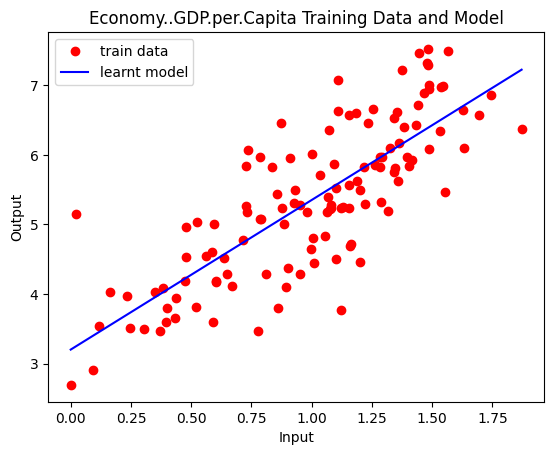

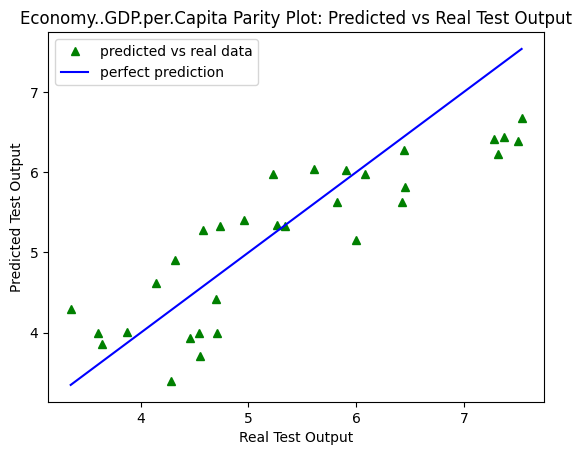

MSE (manual):  0.5588300882911799
RMSE (manual):  0.6435930731840779


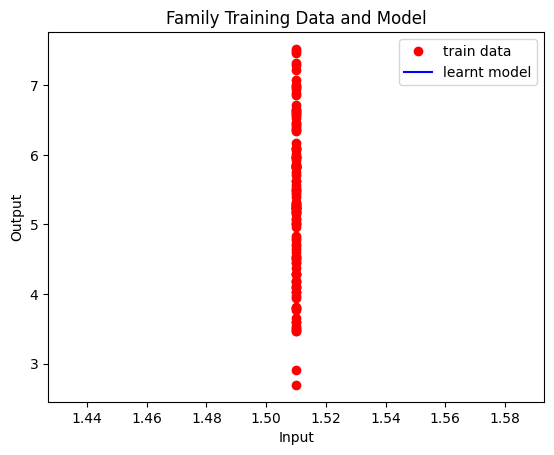

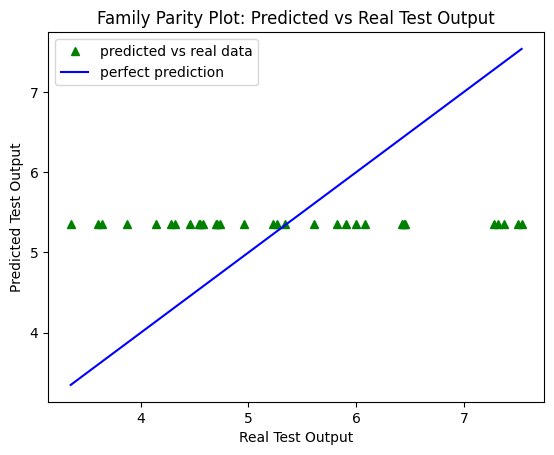

MSE (manual):  1.041084771705255
RMSE (manual):  1.2202335700660534


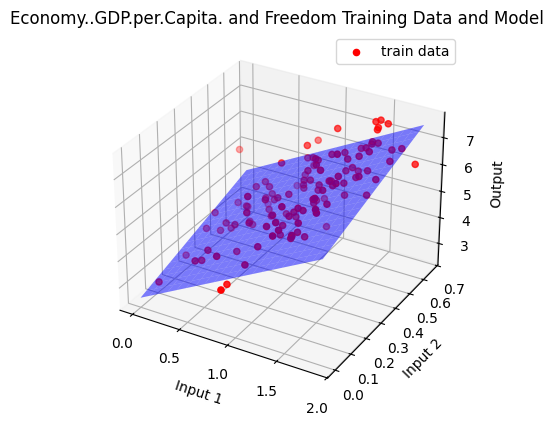

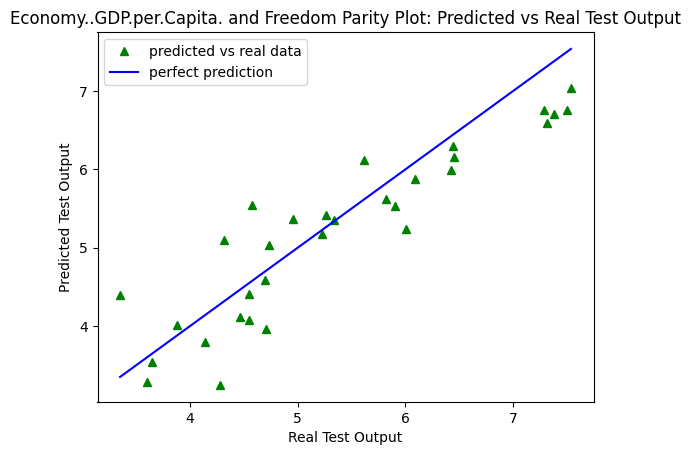

MSE (manual):  0.4385524700466649
RMSE (manual):  0.5270927277244587


In [12]:
# 1. v1_world-happiness-report-2017.csv manual

def runManualTests(filePath):
    inputs,outputs=loadData(filePath,'Economy..GDP.per.Capita.','Happiness.Score')
    manualTrainHappinessModelUniversal(inputs, outputs,title="Economy..GDP.per.Capita")

    inputs,outputs=loadData(filePath,'Family','Happiness.Score')
    manualTrainHappinessModelUniversal(inputs, outputs,title="Family")

    inputs,outputs=loadData(filePath, ['Economy..GDP.per.Capita.','Freedom'], 'Happiness.Score')
    manualTrainHappinessModelUniversal(inputs, outputs, title="Economy..GDP.per.Capita. and Freedom")

filePath=os.path.join(crtDir, 'data','v1_world-happiness-report-2017.csv')
runManualTests(filePath)